In [1]:
import strawberryfields as sf
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1775569665.474718    1218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775569669.319110    1218 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775569672.612900    1218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
def fun_squeeze(n,p,cutoff_dim=50):
    prog = sf.Program(1)
    eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff_dim})
    with prog.context as q:
        Fock(n) | q[0]
        Sgate(p) | q[0]
    results = eng.run(prog)
    state = results.state
    return state

In [5]:
def fun_wigner(state,qmode=0,lims = 5):
    fig = plt.figure()
    X = np.linspace(-lims, lims, 100)
    P = np.linspace(-lims, lims, 100)
    Z = state.wigner(qmode, X, P)
    return Z


NameError: name 'fun_squeeze' is not defined

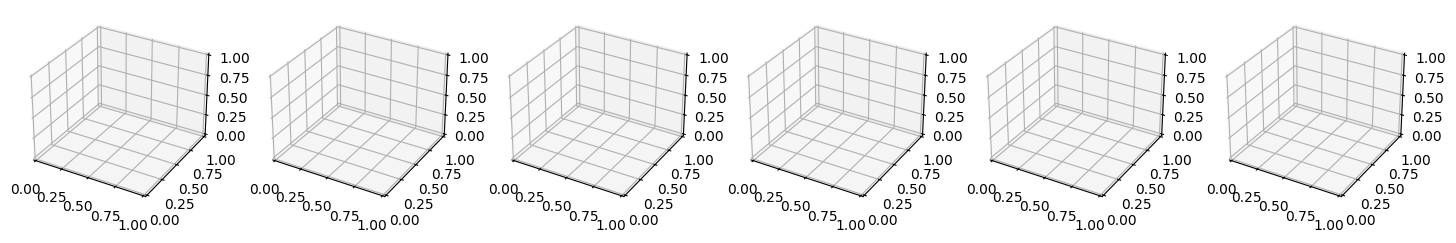

In [2]:
ds = [10,20,50,100,200,500]
fig, axs = plt.subplots(1,len(ds),figsize=(3*len(ds),3*1), subplot_kw = {"projection":"3d"})
Zs = []
states = []
for k,ax in enumerate(axs.flat):
    state = fun_squeeze(0,2,cutoff_dim=ds[k])
    states.append(state)
    Zs.append(plot_wigner(state,ax=ax))

In [4]:
import numpy as np
from mrmustard.lab import Vacuum, Sgate
from mrmustard.visual import plot_wigner


# 1. Definimos o Estado Inicial: Vácuo
# O vácuo é um estado Gaussiano circular no centro do espaço de fase
vac = Vacuum(modes=[0])

# 2. Aplicamos a porta de Squeezing
# r: magnitude do squeezing, phi: ângulo da fase
sq_gate = Sgate(r=1.0, phi=0.0)
squeezed_state = vac >> sq_gate  # Operador >> aplica a porta ao estado

# 3. Geração das Imagens (Função de Wigner)
print("Gerando imagem do Estado de Vácuo...")
plot_wigner(vac)

print("Gerando imagem do Estado Squeezed (Espremido)...")
plot_wigner(squeezed_state)

ModuleNotFoundError: No module named 'mrmustard.visual'

In [3]:
qml.about()

Name: pennylane
Version: 0.42.3
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.10/site-packages
Requires: appdirs, autograd, autoray, cachetools, diastatic-malt, networkx, numpy, packaging, pennylane-lightning, requests, rustworkx, scipy, tomlkit, typing_extensions
Required-by: pennylane_lightning

Platform info:           Linux-6.17.0-20-generic-x86_64-with-glibc2.31
Python version:          3.10.18
Numpy version:           1.26.4
Scipy version:           1.13.0
Installed devices:
- lightning.qubit (pennylane_lightning-0.42.0)
- default.clifford (pennylane-0.42.3)
- default.gaussian (pennylane-0.42.3)
- default.mixed (pennylane-0.42.3)
- default.qubit (pennylane-0.42.3)
- default.qutrit (pennylane-0.42.3)
- default.qutrit.mixed (pennylane-0.42.3)
- default.tensor (pennyla

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Configuração do Dispositivo e Circuito
# ==========================================

# Definimos o dispositivo usando o backend de fock do Strawberry Fields
# cutoff_dim=10 é suficiente para o estado |1> e evita instabilidades.
cutoff = 5
dev = qml.device("strawberryfields.fock", wires=1, cutoff_dim=cutoff)

# Circuito para gerar o estado de Fock |1>
@qml.qnode(dev)
def generate_fock_state():
    # Prepara o estado inicial |1> diretamente
    qml.FockState(1, wires=0)
    # Retorna o estado completo (para calcular a Wigner)
    return qml.state()

# Executa o circuito e obtém o estado
state = generate_fock_state()

# ==========================================
# 2. Cálculo da Função de Wigner
# ==========================================

# Define a grade (grid) para o espaço de fase (q e p)
# Para coincidir com os eixos da sua imagem (de -2.5 a 2.5)
dim = 100
limit = 2.5
q_vec = np.linspace(-limit, limit, dim)
p_vec = np.linspace(-limit, limit, dim)

# O PennyLane usa o backend SF para calcular a Wigner nestes pontos
wigner_data = state.wigner(mode=0, xvec=q_vec, pvec=p_vec)

# Cria a grade de coordenadas para o plot 3D
Q, P = np.meshgrid(q_vec, p_vec)

# ==========================================
# 3. Geração da Imagem 3D + Contorno
# ==========================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- Plot da Superfície 3D ---
# Usamos o colormap 'jet' ou 'RdYlBu' para cores similares à imagem original.
surf = ax.plot_surface(Q, P, wigner_data, cmap=cm.coolwarm,
                       linewidth=0.1, antialiased=True, rstride=1, cstride=1,
                       alpha=0.9)

# --- Plot do Contorno 2D (na base) ---
# zdir='z', offset=-0.1 coloca o contorno no plano inferior (plano z=-0.1)
# para imitar sua imagem onde os eixos z vão de -0.10 a 0.10.
ax.contourf(Q, P, wigner_data, zdir='z', offset=-0.11, cmap=cm.coolwarm)

# --- Configuração dos Eixos e Rótulos ---
# Rotulamos p1 e p2 como na sua imagem
ax.set_xlabel('$p_2$ (q)', fontsize=12)
ax.set_ylabel('$p_1$ (p)', fontsize=12)
ax.set_zlabel('Wigner', fontsize=12)

# Define os limites do eixo Z para destacar a negatividade (-0.1 a 0.1)
ax.set_zlim(-0.11, 0.11)

# Adiciona o título '(a)' como na imagem original
ax.set_title('(a)', fontsize=14)

plt.tight_layout()
plt.show()

DeviceError: Device strawberryfields.fock does not exist. Make sure the required plugin is installed.

In [ ]:
import wigner

wigner.wigner()